imports

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks

plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["font.size"] = 12

configuração

In [19]:
# Ajuste para o seu arquivo
file_path = "../data/processed/cnn_X.npy"

# Frequência de amostragem
fs = 200  # Hz

carregar dados

In [20]:
if not os.path.exists(file_path):
    raise FileNotFoundError(f"Arquivo não encontrado: {file_path}")

ecg_data = np.load(file_path)

print("Shape original:", ecg_data.shape)
print("Dtype:", ecg_data.dtype)

Shape original: (23005, 3600)
Dtype: float32


selecionar um sinal

In [21]:
if ecg_data.ndim == 1:
    ecg_signal = ecg_data
elif ecg_data.ndim == 2:
    ecg_signal = ecg_data[0]
elif ecg_data.ndim == 3:
    ecg_signal = ecg_data[0, :, 0]
else:
    raise ValueError(f"Formato não suportado: {ecg_data.shape}")

ecg_signal = np.asarray(ecg_signal).astype(float)

print("Shape do sinal selecionado:", ecg_signal.shape)
print("Primeiros valores:", ecg_signal[:10])

Shape do sinal selecionado: (3600,)
Primeiros valores: [1.02760565 1.02760565 1.02760565 1.02760565 1.02760565 1.02760565
 1.02760565 1.02760565 1.17447174 1.08635211]


vetor de tempo

In [22]:
t = np.arange(len(ecg_signal)) / fs
duration = len(ecg_signal) / fs

print(f"Amostras: {len(ecg_signal)}")
print(f"Duração: {duration:.2f} s")

Amostras: 3600
Duração: 18.00 s


plot do sinal bruto

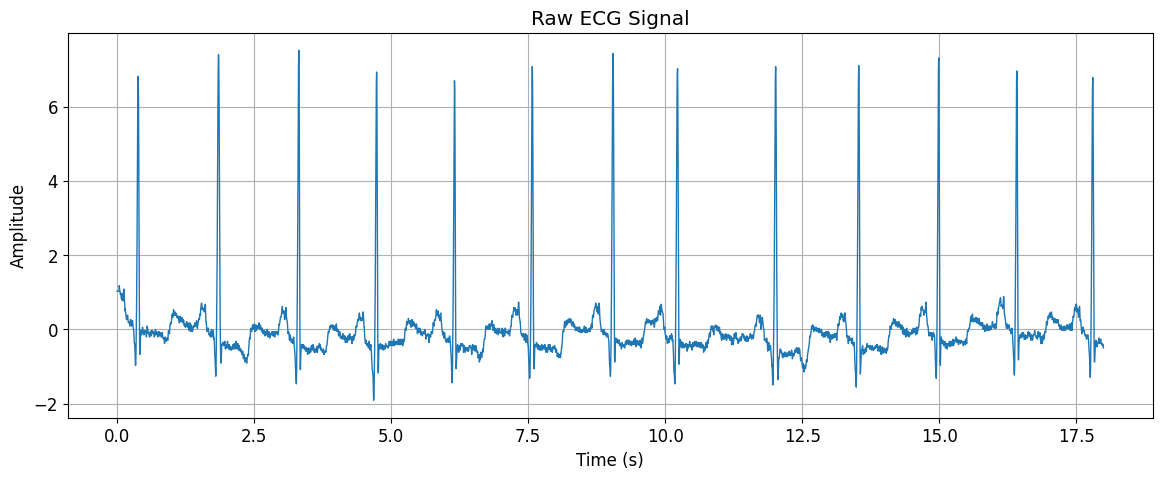

In [23]:
plt.figure()
plt.plot(t, ecg_signal, linewidth=1)
plt.title("Raw ECG Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

função de filtro passa-banda

In [24]:
def bandpass_filter(signal, lowcut=5, highcut=15, fs=200, order=2):
    nyq = 0.5 * fs
    low = lowcut / nyq
    high = highcut / nyq
    b, a = butter(order, [low, high], btype="band")
    filtered = filtfilt(b, a, signal)
    return filtered

aplicar filtro passa-banda

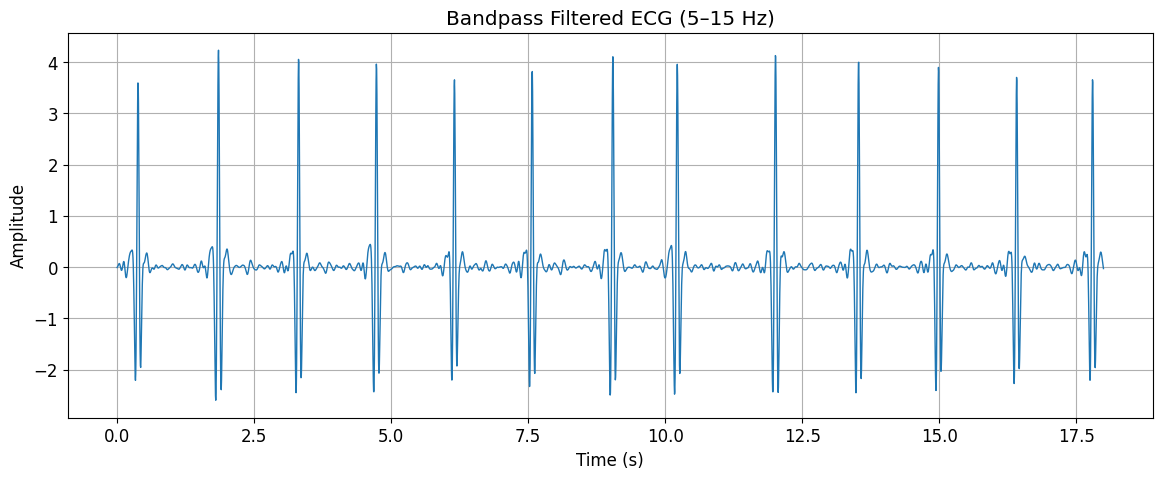

In [25]:
ecg_band = bandpass_filter(ecg_signal, lowcut=5, highcut=15, fs=fs, order=2)

plt.figure()
plt.plot(t, ecg_band, linewidth=1)
plt.title("Bandpass Filtered ECG (5–15 Hz)")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

derivada

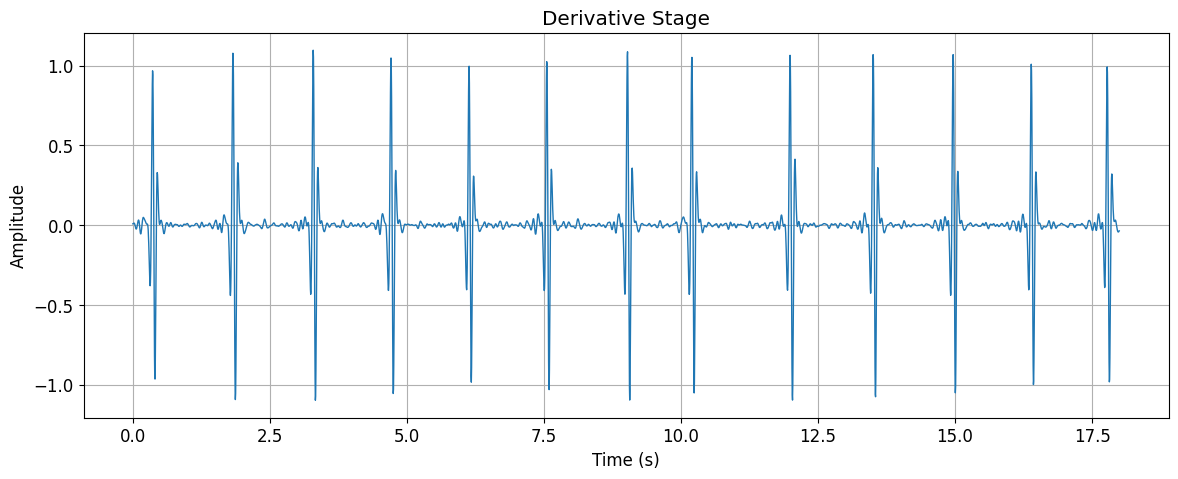

In [26]:
# Derivada discreta simples
ecg_derivative = np.gradient(ecg_band)

plt.figure()
plt.plot(t, ecg_derivative, linewidth=1)
plt.title("Derivative Stage")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

quadrado

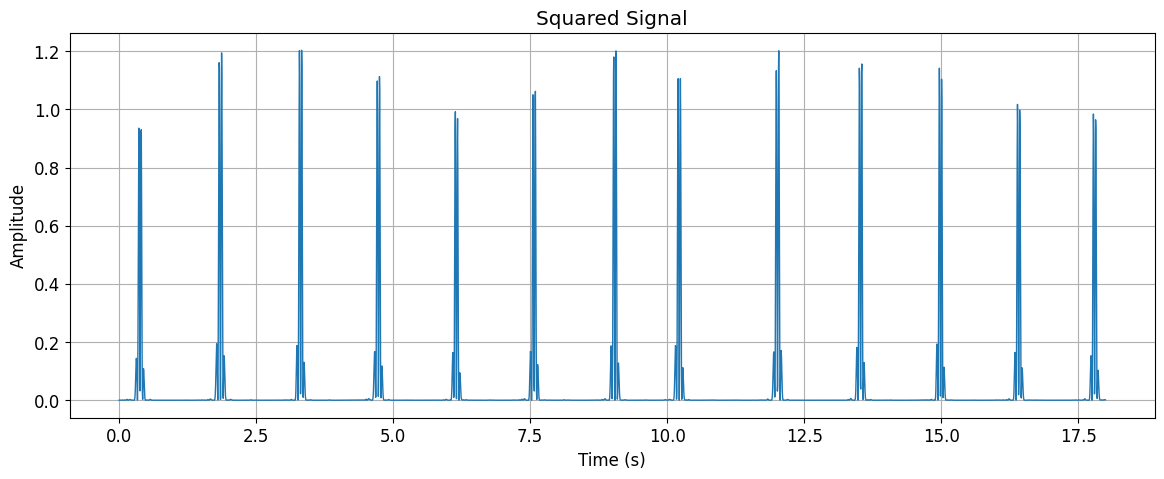

In [27]:
ecg_squared = ecg_derivative ** 2

plt.figure()
plt.plot(t, ecg_squared, linewidth=1)
plt.title("Squared Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

integração por janela móvel

In [28]:
window_ms = 150
window_samples = int((window_ms / 1000) * fs)

if window_samples < 1:
    window_samples = 1

kernel = np.ones(window_samples) / window_samples
ecg_integrated = np.convolve(ecg_squared, kernel, mode="same")

print(f"Window size: {window_samples} samples ({window_ms} ms)")

Window size: 30 samples (150 ms)


plot da integração

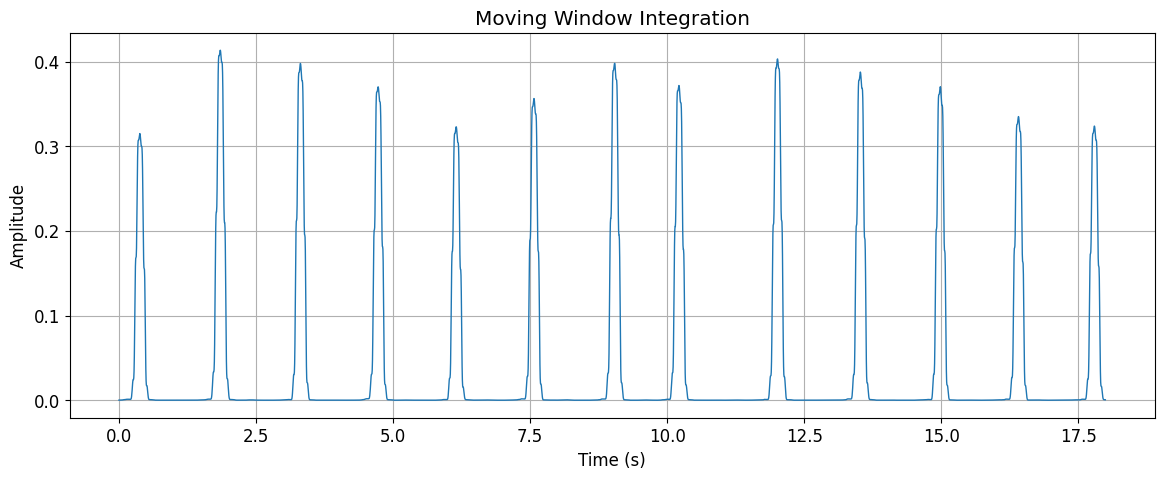

In [29]:
plt.figure()
plt.plot(t, ecg_integrated, linewidth=1)
plt.title("Moving Window Integration")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()

threshold adaptado simples

In [30]:
threshold = np.mean(ecg_integrated) + 0.5 * np.std(ecg_integrated)

print(f"Threshold: {threshold:.4f}")

Threshold: 0.0914


detectar picos

In [31]:
min_distance_samples = int(0.3 * fs)  # 300 ms entre picos (~200 bpm max)

peaks, properties = find_peaks(
    ecg_integrated,
    height=threshold,
    distance=min_distance_samples
)

print(f"Número de picos detectados: {len(peaks)}")

Número de picos detectados: 13


plot picos no sinal integrado

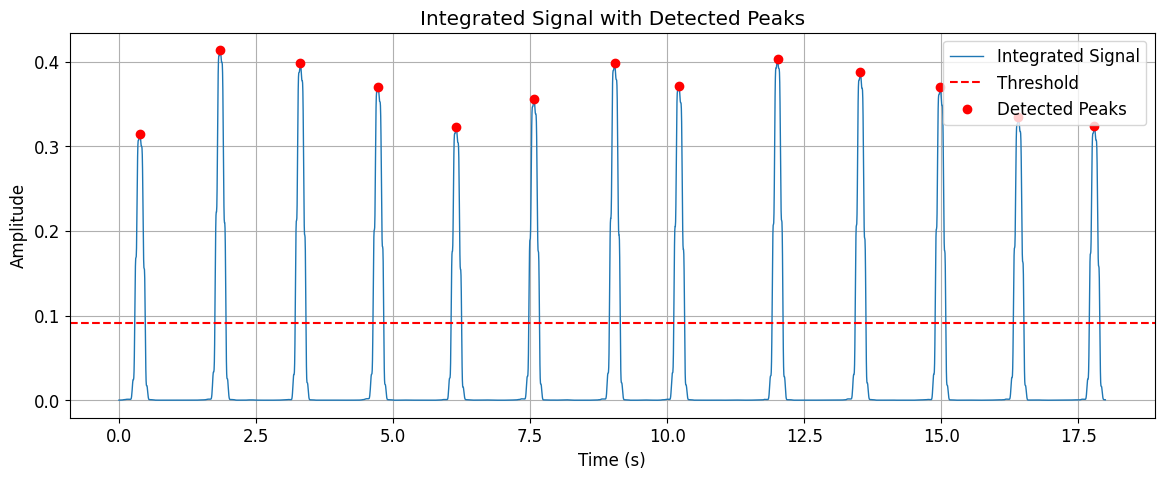

In [32]:
plt.figure()
plt.plot(t, ecg_integrated, label="Integrated Signal", linewidth=1)
plt.axhline(threshold, color="red", linestyle="--", label="Threshold")
plt.plot(t[peaks], ecg_integrated[peaks], "ro", label="Detected Peaks")
plt.title("Integrated Signal with Detected Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

plot picos sobre o ECG bruto

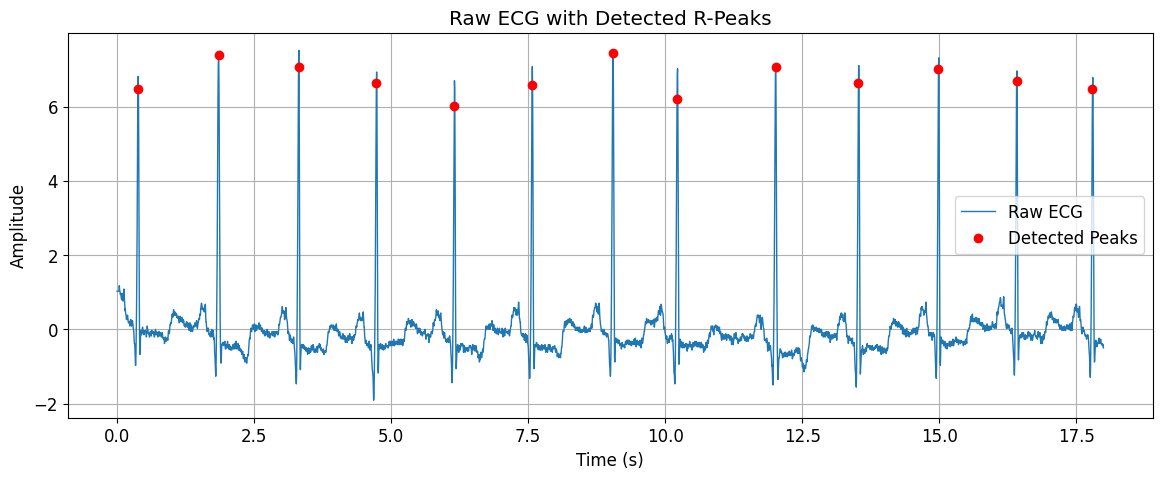

In [33]:
plt.figure()
plt.plot(t, ecg_signal, label="Raw ECG", linewidth=1)
plt.plot(t[peaks], ecg_signal[peaks], "ro", label="Detected Peaks")
plt.title("Raw ECG with Detected R-Peaks")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)
plt.show()

BPM instantâneo

In [34]:
if len(peaks) > 1:
    rr_intervals = np.diff(t[peaks])  # em segundos
    bpm_inst = 60 / rr_intervals
    bpm_mean = np.mean(bpm_inst)

    print("RR intervals (s):", rr_intervals[:10])
    print("Instant BPM:", bpm_inst[:10])
    print(f"Mean BPM: {bpm_mean:.2f}")
else:
    rr_intervals = np.array([])
    bpm_inst = np.array([])
    bpm_mean = 0
    print("Não há picos suficientes para calcular BPM.")

RR intervals (s): [1.47  1.46  1.42  1.42  1.42  1.475 1.17  1.8   1.51  1.46 ]
Instant BPM: [40.81632653 41.09589041 42.25352113 42.25352113 42.25352113 40.6779661
 51.28205128 33.33333333 39.73509934 41.09589041]
Mean BPM: 41.69


plot BPM instantâneo

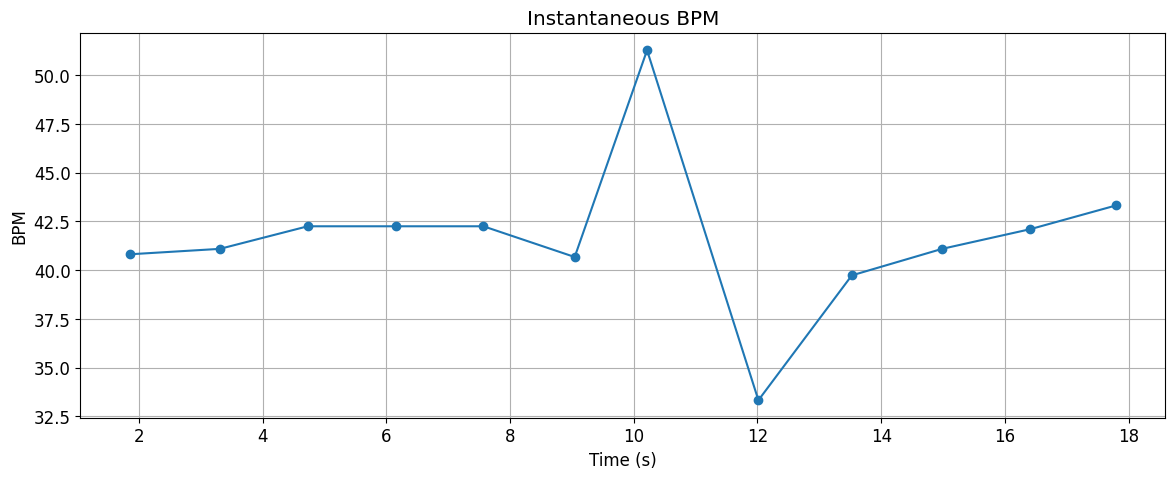

In [35]:
if len(bpm_inst) > 0:
    plt.figure()
    plt.plot(t[peaks][1:], bpm_inst, marker="o")
    plt.title("Instantaneous BPM")
    plt.xlabel("Time (s)")
    plt.ylabel("BPM")
    plt.grid(True)
    plt.show()

zoom das etapas

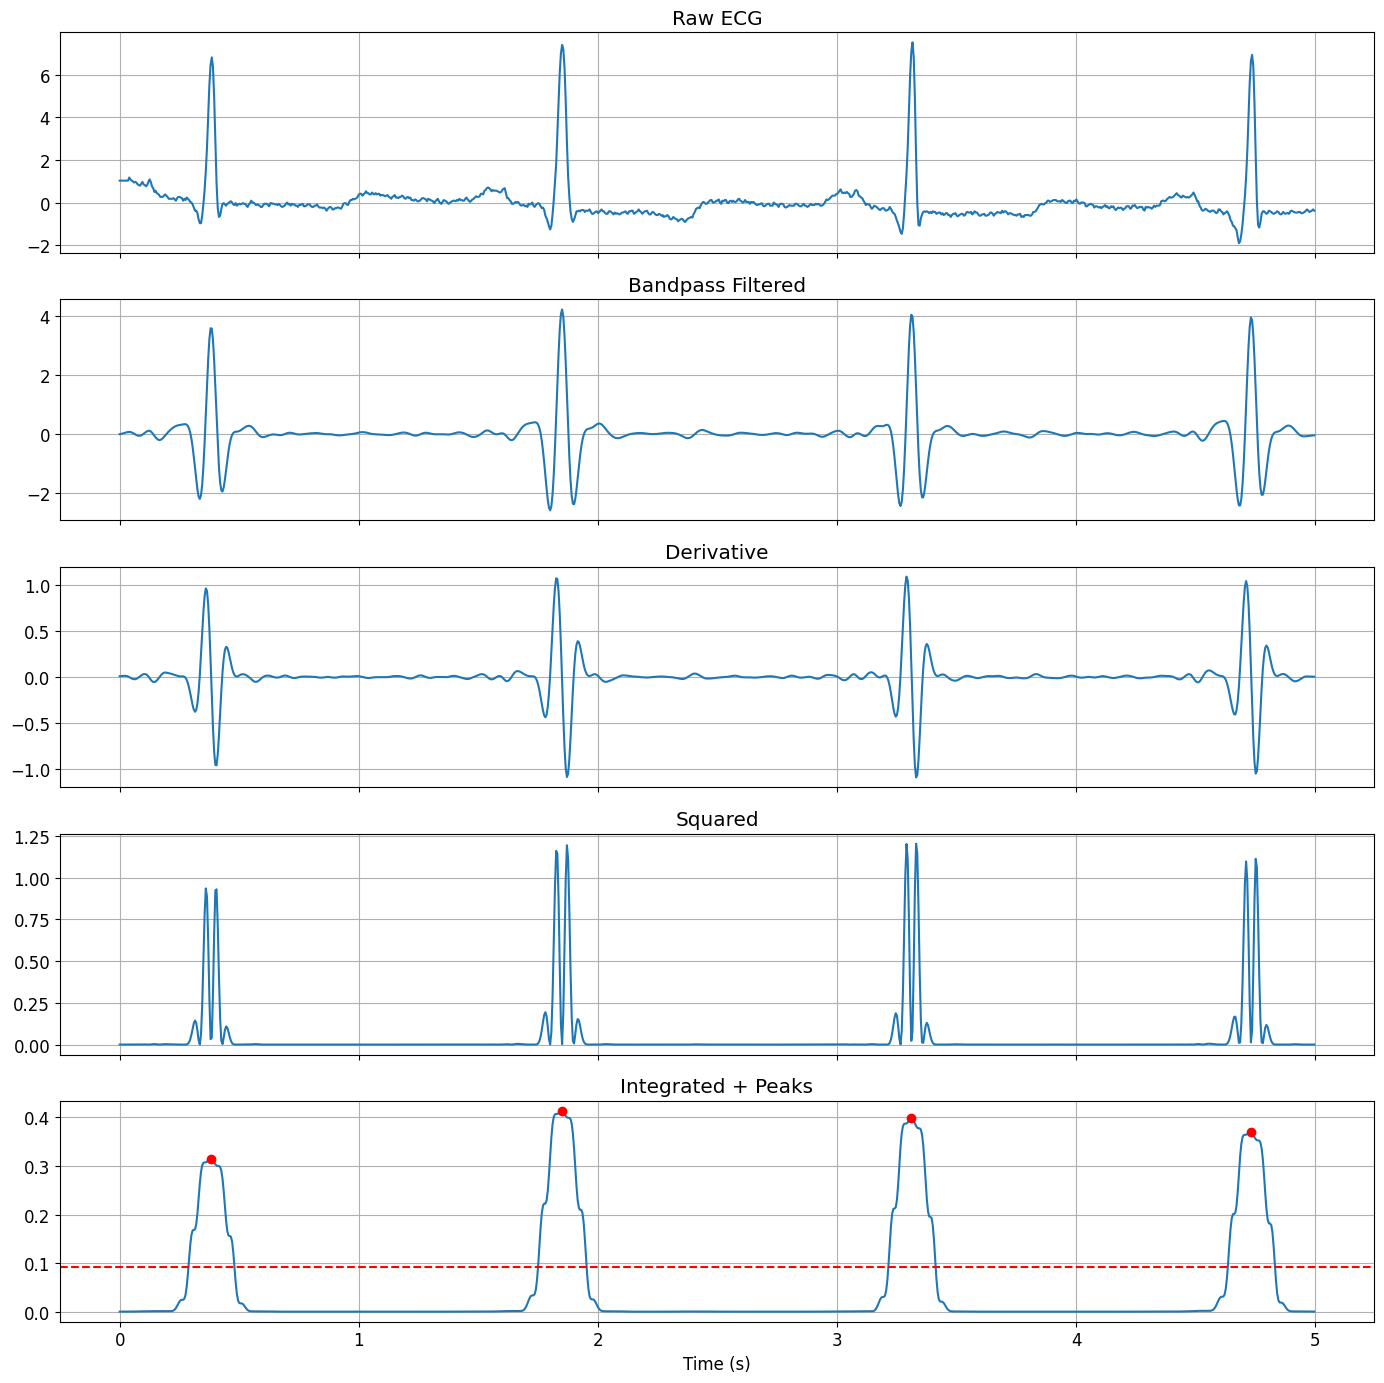

In [36]:
zoom_seconds = 5
zoom_samples = int(zoom_seconds * fs)

fig, axes = plt.subplots(5, 1, figsize=(14, 14), sharex=True)

axes[0].plot(t[:zoom_samples], ecg_signal[:zoom_samples])
axes[0].set_title("Raw ECG")

axes[1].plot(t[:zoom_samples], ecg_band[:zoom_samples])
axes[1].set_title("Bandpass Filtered")

axes[2].plot(t[:zoom_samples], ecg_derivative[:zoom_samples])
axes[2].set_title("Derivative")

axes[3].plot(t[:zoom_samples], ecg_squared[:zoom_samples])
axes[3].set_title("Squared")

axes[4].plot(t[:zoom_samples], ecg_integrated[:zoom_samples], label="Integrated")
axes[4].plot(t[peaks][t[peaks] <= zoom_seconds], ecg_integrated[peaks][t[peaks] <= zoom_seconds], "ro")
axes[4].axhline(threshold, color="red", linestyle="--")
axes[4].set_title("Integrated + Peaks")

for ax in axes:
    ax.grid(True)

axes[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()

conclusão

In [37]:
print("Notebook 02 - Pan-Tompkins Pipeline completed successfully.")
print("Stages implemented:")
print("1. Raw ECG loading")
print("2. Bandpass filtering")
print("3. Derivative")
print("4. Squaring")
print("5. Moving Window Integration")
print("6. Threshold-based peak detection")
print("7. BPM estimation")

Notebook 02 - Pan-Tompkins Pipeline completed successfully.
Stages implemented:
1. Raw ECG loading
2. Bandpass filtering
3. Derivative
4. Squaring
5. Moving Window Integration
6. Threshold-based peak detection
7. BPM estimation
